In [1]:
import numpy as np
import torch
from torch import cuda
from torch.backends import mps
from medmnist import RetinaMNIST
from torchvision.transforms import Lambda
from torchvision.transforms.v2 import Compose, ToImage, ToDtype, Normalize

from util.image_experiment_runner import run_image_experiment

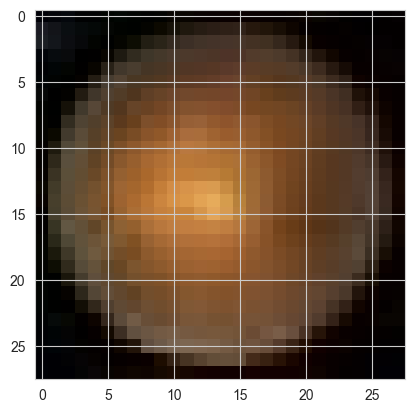

In [6]:
import matplotlib.pyplot as plt
b = np.load('.medmnist\\retinamnist.npz')
b['train_images']

plt.ion()
plt.figure()
plt.imshow(b['train_images'][80])

In [3]:
from torchvision.transforms.v2 import RandomRotation, RandomHorizontalFlip, Resize

train_transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Lambda(lambda x: x if x.shape[0] == 3 else x.repeat(3, 1, 1)),
    RandomRotation(10),
    RandomHorizontalFlip(),
    Normalize(mean=[0.5]*3, std=[0.5]*3)  # Or use ImageNet stats
])

# Test / validation transforms
test_transforms = Compose([
    ToImage(),  # Convert array to image/tensor
    ToDtype(torch.float32, scale=True),  # Convert to float32 and scale to [0,1]
    Lambda(lambda x: x if x.shape[0] == 3 else x.repeat(3, 1, 1)),  # Ensure 3 channels
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1,1]
])

train_dataset = RetinaMNIST(split="train", download=True, transform=train_transforms, size=28)
train_dataset.labels = np.array(train_dataset.labels.squeeze().tolist())
train_dataset.targets = train_dataset.labels

val_dataset = RetinaMNIST(split="val", download=True, transform=test_transforms, size=28)
val_dataset.labels = np.array(val_dataset.labels.squeeze().tolist())

test_dataset = RetinaMNIST(split="test", download=True, transform=test_transforms, size=28)
test_dataset.labels = np.array(test_dataset.labels.squeeze().tolist())

num_classes = len(train_dataset.info['label'])
device = torch.device("cuda" if cuda.is_available() else "mps" if mps.is_available() else "cpu")
print(f"Classes: {num_classes}, Device: {device}")

# Combine test and validation datasets
test_dataset_combined = torch.utils.data.ConcatDataset([test_dataset, val_dataset])
test_labels = np.array(test_dataset.labels.tolist() + val_dataset.labels.tolist())
test_dataset_combined.targets = test_labels

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset_combined)}")

Classes: 5, Device: cpu
Train samples: 1080, Test samples: 520


In [ ]:
data_type = 'retina'
run_image_experiment(device, num_classes, data_type, train_dataset, test_dataset_combined,
                     optimizer=torch.optim.Adam, lr=0.001, weight_decay=0,
                     batch_size=128, es_patience=40, lr_patience=10, lr_factor=0.5,
                     lr_monitor="train_loss", stratified=False,
                     use_determinism=False, shuffle=False, aps_randomized=True)